# Power System Simulation — Final Presentation

Group 5XWG0. Members: Oliwia Hejduk, Joost van der Steen, Jarno de Poorter,
Alejandro Solá Bengoechea.

This notebook walks through everything our package can do, in the order the
three assignments are organized.


## 1. Setup

The package is installable with `uv sync` from the repository root. All the
public APIs are importable from `power_system_simulation`. The big network used in this notebook is **not** committed to the repo — it lives
in a local folder. Set `DATA_DIR` below to wherever you have downloaded the
big_network from SharePoint.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

# Adjust this path to wherever the big_network lives on your machine.
# (Each teammate's path differs because the data isn't committed to the repo.)
DATA_DIR = Path.home() / "Documents" / "Power systems computation" / "datasets" / "big"
NETWORK_JSON = DATA_DIR / "input_network_data.json"
ACTIVE_PROFILE = DATA_DIR / "active_power_profile.parquet"
REACTIVE_PROFILE = DATA_DIR / "reactive_power_profile.parquet"
EV_PROFILE = DATA_DIR / "ev_active_power_profile.parquet"

# From meta_data.json
FEEDER_IDS = [1204, 1304, 1404, 1504, 1604, 1704, 1804, 1904]

print("network:", NETWORK_JSON.exists())
print("active :", ACTIVE_PROFILE.exists())
print("reactive:", REACTIVE_PROFILE.exists())
print("ev     :", EV_PROFILE.exists())

network: True
active : True
reactive: True
ev     : True


## 2. Assignment 1 — Graph processing

`GraphProcessor` is an undirected graph with a designated source vertex,
intended for radial power-grid topology analysis. It exposes two
functionalities used by later assignments:

- `find_downstream_vertices(edge_id)` — every vertex on the far side of an
  edge from the source.
- `find_alternative_edges(disabled_edge_id)` — every currently-disabled
  edge that could be turned on to keep the graph connected if the given
  edge were removed.


In [2]:
from power_system_simulation.graph_processing import GraphProcessor

# Small toy example matching the docstring drawing:
#
#   0 (source) --edge_1(on)-- 2 --edge_9(on)-- 10
#       |                     |
#       |                edge_7(off)
#       |                     |
#       --------edge_3(on)-- 4
#       |                     |
#       |                edge_8(off)
#       |                     |
#       --------edge_5(on)-- 6
gp = GraphProcessor(
    vertex_ids=[0, 2, 4, 6, 10],
    edge_ids=[1, 3, 5, 7, 8, 9],
    vertex_edge_id_pairs=[(0, 2), (0, 4), (0, 6), (2, 4), (4, 6), (2, 10)],
    edge_enabled=[True, True, True, False, False, True],
    source_vertex_id=0,
)

print("downstream of edge 1:", gp.find_downstream_vertices(1))
print("downstream of edge 3:", gp.find_downstream_vertices(3))
print("alternatives if edge 3 fails:", gp.find_alternative_edges(3))
print("alternatives if edge 9 fails:", gp.find_alternative_edges(9))

downstream of edge 1: [2, 10]
downstream of edge 3: [4]
alternatives if edge 3 fails: [7, 8]
alternatives if edge 9 fails: []


## 3. Assignment 2 — Time-series power flow

`PowerFlowRunner` loads a PGM JSON network and a matching pair of active /
reactive load profiles, builds the time-series batch update, runs the
calculation, and aggregates the result into two summary tables.


In [4]:
from power_system_simulation.pgm_runner import PowerFlowRunner

runner = PowerFlowRunner(
    network_json_path=NETWORK_JSON,
    active_profile_path=ACTIVE_PROFILE,
    reactive_profile_path=REACTIVE_PROFILE,
)
runner.run()
print("ran power flow over", runner.active_profile.shape[0], "timestamps")

ran power flow over 35040 timestamps


### 3.1 Voltage summary — one row per timestamp

In [5]:
voltage_table = runner.voltage_table()
voltage_table.head()

,Maximum voltage (pu),Maximum voltage node ID,Minimum voltage (pu),Minimum voltage node ID
Timestamp,,,,
2025-01-01 00:00:00,1.074658,1,1.049898,0
2025-01-01 00:15:00,1.074532,1,1.049891,0
2025-01-01 00:30:00,1.074927,1,1.049916,0
2025-01-01 00:45:00,1.074601,1,1.049894,0
2025-01-01 01:00:00,1.074482,1,1.049885,0


### 3.2 Line summary — one row per line

In [6]:
line_table = runner.line_table()
line_table

,Energy loss (kWh),Maximum loading (pu),Timestamp of maximum loading,Minimum loading (pu),Timestamp of minimum loading
1204,53.619019,5.824780e-02,2025-11-07 09:45:00,4.447163e-03,2025-10-08 12:45:00
1205,0.184181,5.680893e-03,2025-04-07 10:30:00,4.082249e-07,2025-03-04 17:15:00
1206,54.899474,5.442560e-02,2025-11-05 23:15:00,3.731235e-03,2025-10-08 12:45:00
1207,0.224576,4.752569e-03,2025-05-29 02:30:00,4.118517e-07,2025-12-29 15:30:00
1208,50.536788,5.648105e-02,2025-11-07 09:45:00,3.791173e-03,2025-10-08 12:45:00
...,...,...,...,...,...
2006,0.008016,2.444916e-07,2025-10-02 19:45:00,2.399379e-07,2025-11-05 07:30:00
2007,0.007916,2.445316e-07,2025-10-08 17:45:00,2.401123e-07,2025-11-04 22:30:00
2008,0.009355,2.444854e-07,2025-10-02 20:15:00,2.395951e-07,2025-11-07 15:00:00
2009,0.009017,2.444597e-07,2025-08-13 05:00:00,2.398150e-07,2025-11-05 23:15:00


### 3.3 A picture — voltage band over time

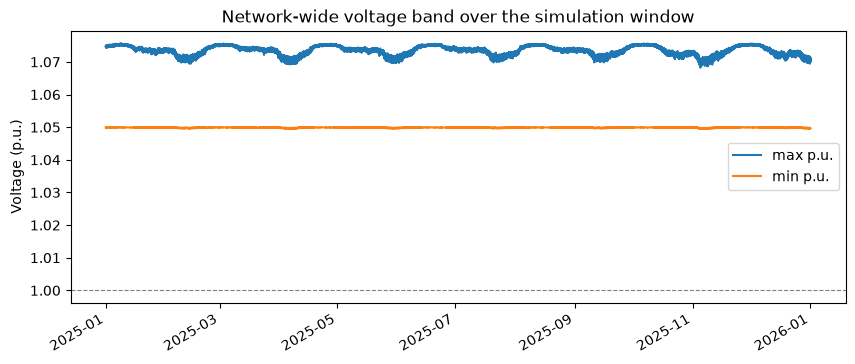

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(voltage_table.index, voltage_table["Maximum voltage (pu)"], label="max p.u.")
ax.plot(voltage_table.index, voltage_table["Minimum voltage (pu)"], label="min p.u.")
ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.8)
ax.set_ylabel("Voltage (p.u.)")
ax.set_title("Network-wide voltage band over the simulation window")
ax.legend()
fig.autofmt_xdate()
plt.show()

## 4. Assignment 3 — LV grid analytics

A3 ties A1 and A2 together. We start with an `LVGrid` that validates the
input data; the three analyses below all build on top of it.


### 4.1 Input validation

`LVGrid` runs ten validation checks on construction (PGM validity, exactly
one transformer + one source, valid feeder IDs, feeders start at the
transformer's LV side, initial state is connected and acyclic, matching
timestamps and IDs across the three profiles, enough EV profiles). If any
check fails it raises a specific exception so the caller knows what went
wrong.


In [8]:
from power_system_simulation.lv_grid import LVGrid, OptimizationCriteria

grid = LVGrid(
    network_json_path=NETWORK_JSON,
    active_profile_path=ACTIVE_PROFILE,
    reactive_profile_path=REACTIVE_PROFILE,
    ev_profile_path=EV_PROFILE,
    feeder_ids=FEEDER_IDS,
)

print("transformer id    :", grid.transformer_id)
print("source id         :", grid.source_id)
print("LV busbar (node)  :", grid.transformer_lv_node)
print("sym_load ids      :", grid.sym_load_ids)
print("feeder line ids   :", grid.feeder_ids)
print("timestamps        :", grid.active_profile.shape[0])
print("EV profiles in pool:", grid.ev_profile.shape[1])

transformer id    : 803
source id         : 802
LV busbar (node)  : 1
sym_load ids      : [804, 805, 806, 807, 808, 809, 810, 811, 812, 813, 814, 815, 816, 817, 818, 819, 820, 821, 822, 823, 824, 825, 826, 827, 828, 829, 830, 831, 832, 833, 834, 835, 836, 837, 838, 839, 840, 841, 842, 843, 844, 845, 846, 847, 848, 849, 850, 851, 852, 853, 854, 855, 856, 857, 858, 859, 860, 861, 862, 863, 864, 865, 866, 867, 868, 869, 870, 871, 872, 873, 874, 875, 876, 877, 878, 879, 880, 881, 882, 883, 884, 885, 886, 887, 888, 889, 890, 891, 892, 893, 894, 895, 896, 897, 898, 899, 900, 901, 902, 903, 904, 905, 906, 907, 908, 909, 910, 911, 912, 913, 914, 915, 916, 917, 918, 919, 920, 921, 922, 923, 924, 925, 926, 927, 928, 929, 930, 931, 932, 933, 934, 935, 936, 937, 938, 939, 940, 941, 942, 943, 944, 945, 946, 947, 948, 949, 950, 951, 952, 953, 954, 955, 956, 957, 958, 959, 960, 961, 962, 963, 964, 965, 966, 967, 968, 969, 970, 971, 972, 973, 974, 975, 976, 977, 978, 979, 980, 981, 982, 983, 984, 985,

Quick demonstration that a bad input is rejected — here we pass a
non-existent feeder ID and `FeederIdNotALineError` is raised.


In [ ]:
from power_system_simulation.lv_grid import FeederIdNotALineError

try:
    LVGrid(
        network_json_path=NETWORK_JSON,
        active_profile_path=ACTIVE_PROFILE,
        reactive_profile_path=REACTIVE_PROFILE,
        ev_profile_path=EV_PROFILE,
        feeder_ids=[16, 99999],
    )
except FeederIdNotALineError as e:
    print("caught as expected:", e)

caught as expected: Feeder ID 16 is not a valid line ID.


### 4.2 EV penetration analysis  

Given an EV penetration level (e.g. 20%), randomly assign EV charging
profiles from the pool to a subset of households, distributed across the
feeders according to the spec. Then run a time-series power flow with the
new loads and produce the same two aggregation tables as in Assignment 2.





In [10]:
voltage_table_ev, line_table_ev, assignment_table = grid.simulate_ev_penetration(
    penetration_level=20,
    seed=42,
    return_assignment=True,
)

print("Number of EVs assigned:", len(assignment_table))
print("Minimum voltage [p.u.]:", voltage_table_ev["min_voltage_pu"].min())
print("Maximum line loading:", line_table_ev["max_loading"].max())
print("Line with maximum loading:", line_table_ev["max_loading"].idxmax())
print("Total line losses [kWh]:", line_table_ev["energy_loss_kwh"].sum())

assignment_table

Number of EVs assigned: 80
Minimum voltage [p.u.]: 1.0495952800858404
Maximum line loading: 0.08121517001407474
Line with maximum loading: 1612
Total line losses [kWh]: 7869.5791254257365


,feeder_id,sym_load_id,ev_profile
0,1204,842,306
1,1204,819,279
2,1204,832,186
3,1204,845,274
4,1204,822,355
...,...,...,...
75,1904,1167,328
76,1904,1195,384
77,1904,1192,245
78,1904,1171,315


### 4.3 Optimal tap position 

Sweep every possible tap position of the transformer, re-run the full
time-series power flow for each, and return the tap that minimises the
chosen criterion (total energy loss across lines, or average voltage
deviation from 1 p.u.). The criterion is a user-selectable argument. The default is set as the voltage deviation. 


In [13]:
optimal_tap_energy = grid.optimize_tap_position(criteria=OptimizationCriteria.MIN_VOLTAGE_DEVIATION)
print(f"Optimal tap for minimum voltage deviation: {optimal_tap_energy}")
optimal_tap_energy = grid.optimize_tap_position(criteria=OptimizationCriteria.MIN_ENERGY_LOSS)
print(f"Optimal tap for minimum energy loss: {optimal_tap_energy}")

Optimal tap for minimum voltage deviation: 1
Optimal tap for minimum energy loss: 5


### 4.4 N-1 calculation

Given a line that is going out of service, find every currently-disabled
line that could be switched in to keep the grid connected, then run the
full time-series power flow for each alternative. Return a summary table
with one row per alternative and the maximum loading information.


In [14]:
# Simulate line fault on some line in the network
faulted_line_id = 1204

# Execute the N-1 contingency calculation from our validated grid object
n1_summary_table = grid.calculate_n_minus_1(line_id=faulted_line_id)

# Render the operational summary table
if n1_summary_table.empty:
    print("No valid alternative configurations exist.")
else:
    print("Scenarios ranked by maximum strain:")

n1_summary_table

Scenarios ranked by maximum strain:


,Alternative Line ID,Maximum Loading,Line ID of Maximum Loading,Timestamp of Maximum Loading
0,2004,0.129424,1310,2025-11-05 02:00:00


## 5. Collaboration and lessons learned  *(~2 minutes, all of us)*

**How we worked together:**

- All work merged through pull requests with branch protection (2 approvals
  required, CI must pass, conversations resolved).
- Branches were stacked when one chunk depended on another that hadn't
  merged yet (e.g. A3 validation stacked on the A2 runner branch).
- We used pre-commit + ruff so formatting was never a CI surprise.
- pytest with 95%+ coverage was enforced by CI.

**On AI tools:**

We used AI assistants heavily across the project. Where they helped:
scaffolding boilerplate code, explaining unfamiliar libraries like
`power-grid-model`, drafting test cases, and catching small bugs during
PR reviews. Where they didn't: we lost time once when an AI suggested a
data format that didn't match the actual parquet files, and it can't
replace a teammate decision about whose API wins when two of us start
the same chunk in parallel. The lesson is the obvious one — AI is great
for unblocking and explaining, but it can't make team decisions for you.

**Things we'd do differently next time:**

- Lock down the API shape together at the start of each assignment so two
  people don't write competing versions of the same thing in parallel.
- Talk about misunderstandings in the input data format earlier (we lost a
  day on a parser that assumed the wrong tuple shape).
- Decide upfront whether each new feature gets stacked on an open PR or
  branched off main, instead of figuring it out per-PR.
- Use the mentor and TA for design questions earlier rather than during
  the final week.
